# Exploratory Data Analysis

Kham pha phan phoi luong mua, target 6 gio toi va cac feature thoi tiet.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.aq_course_ml.config import PROCESSED_DATA_PATH

In [2]:
df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['timestamp'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56094 entries, 0 to 56093
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   timestamp                   56094 non-null  datetime64[ns]
 1   rain                        56094 non-null  float64       
 2   precipitation               56094 non-null  float64       
 3   temperature_2m              56094 non-null  float64       
 4   relative_humidity_2m        56094 non-null  int64         
 5   dew_point_2m                56094 non-null  float64       
 6   pressure_msl                56094 non-null  float64       
 7   surface_pressure            56094 non-null  float64       
 8   wind_speed_10m              56094 non-null  float64       
 9   wind_direction_10m          56094 non-null  int64         
 10  wind_gusts_10m              56094 non-null  float64       
 11  cloud_cover                 56094 non-null  int64     

,timestamp,rain,precipitation,temperature_2m,relative_humidity_2m,dew_point_2m,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,...,rain_roll_sum_6h,rain_roll_sum_12h,precipitation_lag_1h,precipitation_roll_sum_6h,temp_lag_1h,humidity_lag_1h,dew_point_lag_1h,cloud_cover_lag_1h,target_rain_next_6h,target_rain_alert_6h
0,2020-01-01 12:00:00,0.0,0.0,22.4,69,16.5,1024.1,1022.0,8.5,144,...,0.0,1.0,0.0,0.0,23.0,65.0,16.1,98.0,3.3,1
1,2020-01-01 13:00:00,0.1,0.1,21.9,73,16.9,1023.1,1021.0,9.3,152,...,0.0,0.6,0.0,0.0,22.4,69.0,16.5,98.0,3.2,1
2,2020-01-01 14:00:00,0.6,0.6,21.2,79,17.5,1022.4,1020.3,9.0,157,...,0.1,0.4,0.1,0.1,21.9,73.0,16.9,95.0,2.6,1
3,2020-01-01 15:00:00,1.0,1.0,20.6,86,18.2,1022.1,1020.0,9.6,160,...,0.7,0.9,0.6,0.7,21.2,79.0,17.5,93.0,1.6,1
4,2020-01-01 16:00:00,0.7,0.7,20.3,88,18.3,1022.1,1020.0,9.0,164,...,1.7,1.8,1.0,1.7,20.6,86.0,18.2,99.0,0.9,0


In [3]:
df[['rain', 'precipitation', 'target_rain_next_6h']].describe()

,rain,precipitation,target_rain_next_6h
count,56094.000000,56094.000000,56094.000000
mean,0.246952,0.246952,1.481568
std,1.047987,1.047987,4.387461
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.100000,0.100000,0.700000
max,26.400000,26.400000,98.100000


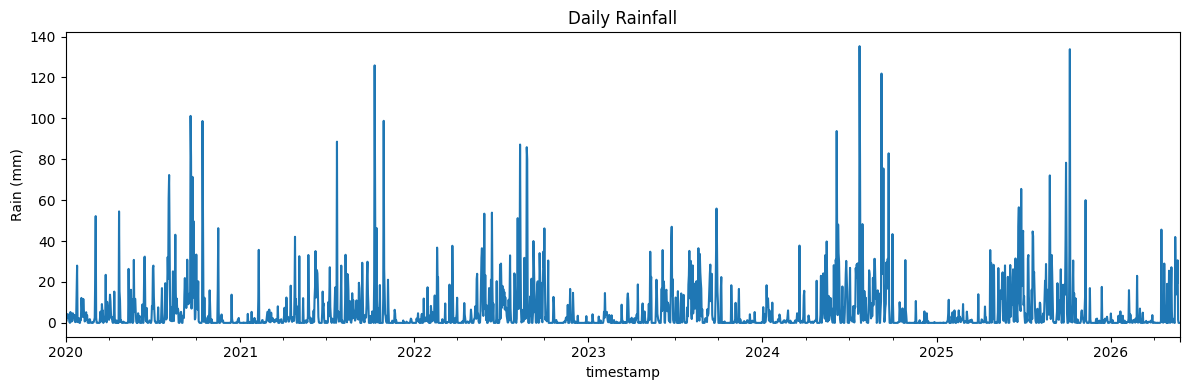

In [4]:
daily = df.set_index('timestamp')['rain'].resample('D').sum()
daily.plot(figsize=(12, 4), title='Daily Rainfall')
plt.ylabel('Rain (mm)')
plt.tight_layout()

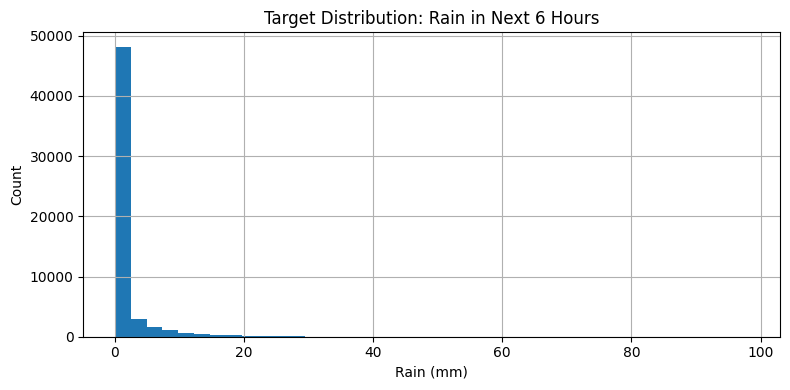

In [5]:
df['target_rain_next_6h'].hist(bins=40, figsize=(8, 4))
plt.title('Target Distribution: Rain in Next 6 Hours')
plt.xlabel('Rain (mm)')
plt.ylabel('Count')
plt.tight_layout()